## Import the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Load and preprocess the dataset

In [2]:
# Generate a synthetic dataset with 300 samples and 2 features
data = make_blobs(n_samples=300, centers=4, n_features=2, random_state=42)

# Standardize the dataset
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[0])

# Implement the K-means algorithm

In [5]:
def initialize_centroids(data, k):
    """Randomly initialize the centroids from the data points."""
    np.random.seed(42)
    random_indices = np.random.choice(data.shape[0], size=k, replace=False)
    centroids = data[random_indices]
    return centroids

def compute_distances(data, centroids):
    """Compute the distances between each data point and centroids."""
    distances = np.zeros((data.shape[0], centroids.shape[0]))
    for i, centroid in enumerate(centroids):
        distances[:, i] = np.linalg.norm(data - centroid, axis=1)
    return distances

def assign_clusters(distances):
    """Assign each data point to the closest centroid."""
    clusters = np.argmin(distances, axis=1)
    return clusters

def update_centroids(data, clusters, k):
    """Update the centroids by computing the mean of the points in each cluster."""
    new_centroids = np.zeros((k, data.shape[1]))
    for i in range(k):
        cluster_points = data[clusters == i]
        if len(cluster_points) > 0:
            new_centroids[i] = np.mean(cluster_points, axis=0)

    return new_centroids

def k_means(data, k, max_iterations=100):
    """Implement the K-means clustering algorithm."""
    centroids = initialize_centroids(data, k)
    for _ in range(max_iterations):
        # Step 1: Compute distances from data points to centroids
        dis=compute_distances(data, centroids)#this function is written already in file

        # Step 2: Assign clusters
        clusters=assign_clusters(dis)#this function also exist in this file


        # Step 3: Update centroids function exist in it
        new_centroids=update_centroids(data, clusters, k)


        # Step 4: Check for convergence
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return centroids, clusters

# Evaluate the results

In [4]:
# Choose the number of clusters, K
k = 5

# Run the K-means algorithm
centroids, clusters = k_means(data_scaled, k)

# Compute the total within-cluster sum of squares
wcss = np.sum([np.sum(np.square(data_scaled[clusters == i] - centroids[i])) for i in range(k)])
print("Total within-cluster sum of squares: ", wcss)

Total within-cluster sum of squares:  15.710009428677694


# Visualize the clusters

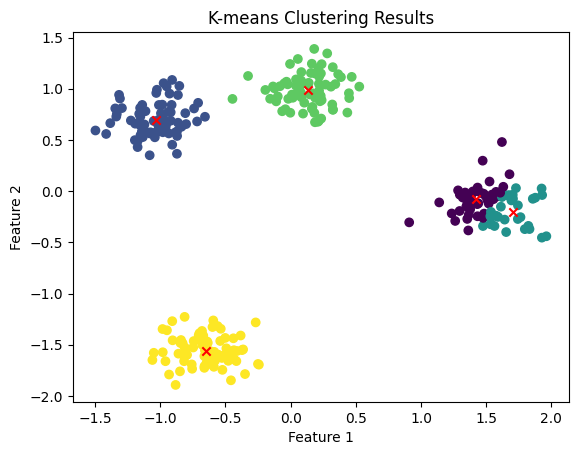

In [ ]:
# Plot the dataset with the assigned clusters and centroids
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=clusters, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-means Clustering Results')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
from sklearn.datasets import make_blobs #to generate sample data

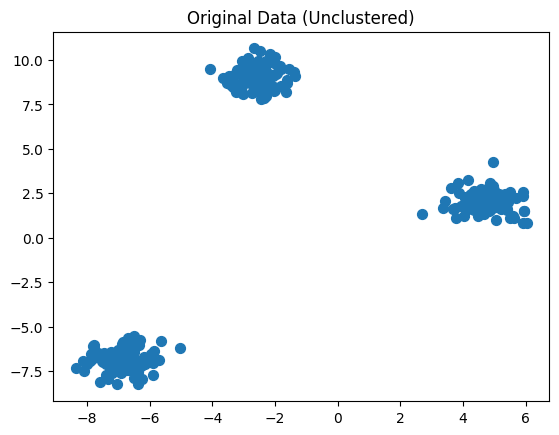

In [ ]:
# Create dataset with 3 centers (clusters)
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.6,
random_state=42)
# Visualize the raw data
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Original Data (Unclustered)")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
# Fit KMeans on the data
kmeans.fit(X)
# Get cluster centers and labels
centers = kmeans.cluster_centers_
labels = kmeans.labels_

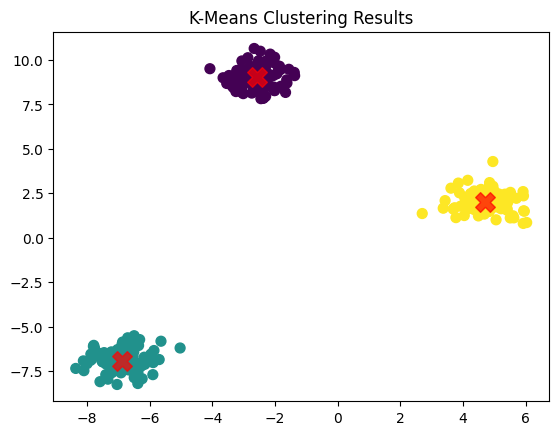

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
# Plot cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7,
marker='X')
plt.title("K-Means Clustering Results")
plt.show()

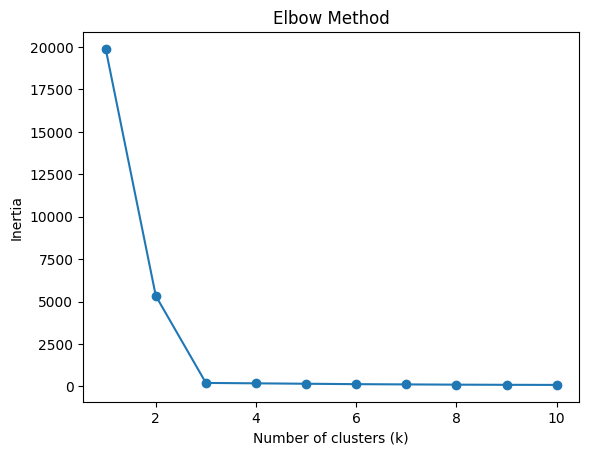

In [ ]:
inertia = [] # Sum of squared distances to nearest cluster center
# Test k values from 1 to 10
for k in range(1, 11):

  km = KMeans(n_clusters=k, random_state=42)
  km.fit(X)
  inertia.append(km.inertia_)
# Plot the elbow curve
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()